# Tracking bound particles with a hook: tidal stream formation

This example shows how to write a **custom hook** that measures a quantity *during* a run — here, the number of particles still gravitationally bound to a satellite as it dissolves into a tidal stream.

We put a Plummer-sphere progenitor on a near-circular orbit in the Milky Way potential. As it orbits, the host's tidal field strips stars, forming a stream. A `BoundednessHook` runs at each output snapshot and computes the bound-particle count via **iterative unbinding**, streaming the live count to the progress bar.

**Why a hook and not a post-run accessor?** Boundedness is an *iterative reduction over the live state* — exactly the kind of thing that is natural to accumulate on the fly. (You could also compute it post-run from snapshots; the hook shines when you want it streamed live or at finer-than-`dt_out` cadence.)

## 1. External field and progenitor

We use the NFW halo component of galpy's `MWPotential2014` as the host, and sample a $10^8\,M_\odot$ Plummer sphere placed at $R = 15$ kpc on a circular orbit.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from galpy.potential import MWPotential2014

from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.dynamics import self_gravity
from tambora.dynamics.hooks import Hook, EveryOutput

# --- host potential (NFW halo of MWPotential2014) ---
host = MWPotential2014[2]
host.turn_physical_on(ro=8 * u.kpc, vo=220 * u.km / u.s)

# --- progenitor orbit + sampling ---
N = 3000
R = 15.0                                   # orbital radius [kpc]
EPS = 0.05                                 # softening [kpc]
vc = host.vcirc(R * u.kpc, quantity=True).to(u.km / u.s).value

pos, vel, mass = mkPlummer_galpy(m=1e8, b=0.25, n=N,
                                 center_pos=[R, 0, 0],
                                 center_vel=[0, vc, 0])

sim = Sim()
sim.add_external_pot(host)
sim.add_particles('sat', pos, vel, mass)

## 2. The iterative unbinding calculation

A star is bound to the satellite if its energy *in the satellite's frame* is negative:

$$E_i = \tfrac{1}{2}\,|\mathbf{v}_i - \mathbf{v}_\mathrm{com}|^2 + \Phi_{\mathrm{self},i} < 0$$

This is circular — $\mathbf{v}_\mathrm{com}$ and $\Phi_\mathrm{self}$ depend on *which* stars are bound — so we iterate:

1. Start with all stars bound.
2. Compute the COM velocity and self-potential **from the currently-bound set**.
3. Drop stars with $E_i \ge 0$.
4. Repeat until the bound set stops changing.

Note the criterion is **internal**: only the satellite's own self-gravity and COM-frame kinetic energy enter. The host's tidal field is what *drives* the stripping, but it does not appear in the binding test. We reuse tambora's `self_gravity` solver to get the specific self-potential of the bound subset.

In [2]:
def bound_mask(pos, vel, mass, eps, method='falcON', theta=0.6, max_iter=50):
    """Boolean mask of self-bound particles via iterative unbinding.

    pos [kpc], vel [kpc/Gyr, internal units], mass [Msun]. Returns (N,) bool.
    """
    bound = np.ones(len(mass), dtype=bool)
    for _ in range(max_iter):
        mb = mass[bound]
        v_com = (mb[:, None] * vel[bound]).sum(0) / mb.sum()
        kw = dict(eps=eps, theta=theta) if method == 'falcON' else dict(eps=eps)
        _, phi = self_gravity(pos[bound], mb, method=method, **kw)   # specific potential
        E = 0.5 * np.sum((vel[bound] - v_com) ** 2, axis=-1) + phi
        keep = E < 0
        if keep.all():
            break                       # converged: nothing new unbound
        idx = np.flatnonzero(bound)
        bound[idx[~keep]] = False        # monotonic: once unbound, stays unbound
        if not bound.any():
            break
    return bound

## 3. The hook

A hook is any callable taking a `StepState` (a live, read-only view of the current step). We subclass `Hook` so it carries a `default_cadence`. Here we:

- grab the `'sat'` component view (`state.component('sat')`),
- run iterative unbinding on its live `pos()/vel()/mass()` (already in internal units),
- accumulate the time and bound count on `self`, and
- push the live count to the progress bar with `state.report(...)`.

It is a pure *observer* — it never modifies the state.

In [3]:
class BoundednessHook(Hook):
    """Track the number of self-bound particles of a component over time."""

    default_cadence = EveryOutput()

    def __init__(self, component, eps, method='falcON', theta=0.6, max_iter=50):
        self.component = component
        self.eps = eps
        self.method = method
        self.theta = theta
        self.max_iter = max_iter
        self.t = []
        self.n_bound = []
        self.last_mask = None            # bound mask at the most recent fire

    def __call__(self, state):
        c = state.component(self.component)
        mask = bound_mask(c.pos(), c.vel(), c.mass(),
                          self.eps, self.method, self.theta, self.max_iter)
        n = int(mask.sum())
        self.t.append(state.t)
        self.n_bound.append(n)
        self.last_mask = mask
        state.report(n_bound=n)

## 4. Register and run

`add_hook` uses the hook's `default_cadence` (`EveryOutput`) unless you pass one. Watch the `n_bound=` field on the progress bar tick down as the stream forms.

In [4]:
hook = BoundednessHook('sat', eps=EPS)
sim.add_hook(hook)

sim.run(t_end=2.5, dt=0.005, dt_out=0.25,
        method='falcON', eps=EPS, theta=0.6)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:04<00:00, 120.98it/s, n_bound=1081]


## 5. Bound fraction vs. time

The results live on the hook object (`hook.t`, `hook.n_bound`) — the reference you kept when you constructed it.

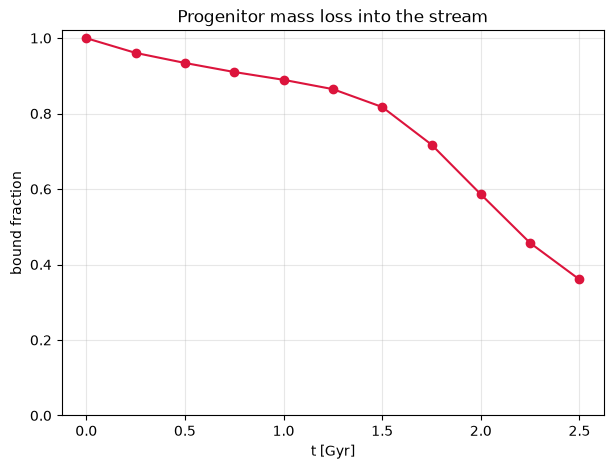

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(hook.t, np.array(hook.n_bound) / N, 'o-', c='crimson')
plt.xlabel('t [Gyr]')
plt.ylabel('bound fraction')
plt.title('Progenitor mass loss into the stream')
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.show()

## 6. The stream

Using the bound mask from the final snapshot (`hook.last_mask`), we colour the surviving bound remnant against the stripped stream. The leading/trailing tails are the classic signature of tidal disruption.

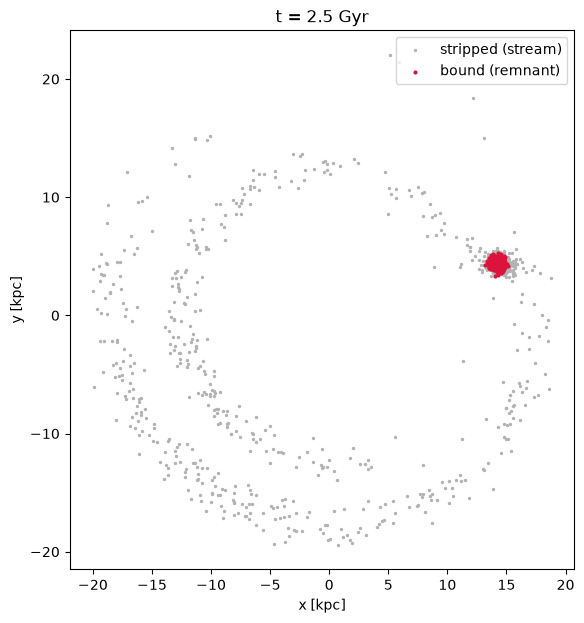

In [6]:
mask = hook.last_mask
x, y = sim.sat.x(-1), sim.sat.y(-1)      # final snapshot, physical kpc

plt.figure(figsize=(7, 7))
plt.scatter(x[~mask], y[~mask], s=2, c='0.7', label='stripped (stream)')
plt.scatter(x[mask], y[mask], s=4, c='crimson', label='bound (remnant)')
plt.gca().set_aspect('equal')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title(f't = {sim.times[-1]:.1f} Gyr')
plt.legend(loc='upper right')
plt.show()

## Notes

- **Observing vs. mutating.** This hook only reads the state. Mutating hooks (e.g. actually *removing* unbound particles) are a planned extension; `add_hook` currently rejects any hook with `mutates = True`.
- **Cadence.** `EveryOutput` recomputes boundedness once per snapshot. Because each call re-runs iterative unbinding (with a falcON solve per iteration), a finer cadence costs more — use `EveryNSteps`/`EveryNOutputs` to trade resolution for speed.
- **Reuse.** `bound_mask` is a plain function, so the same calculation backs both this hook and any post-run analysis (e.g. a future `Sim.boundedness()` accessor). Keeping the physics in one function is what lets the live-hook and post-run paths agree.
- **Binding criterion.** Only the satellite's self-gravity enters the energy test; the host potential drives stripping but is deliberately excluded from the bound/unbound decision.